Lab 4

In [66]:
import cv2
import time
import gymnasium as gym
from google.colab import output
from google.colab.patches import cv2_imshow
import numpy as np
mode = "rgb_array"
if mode == "Node":
    mode = None

(18, 3, 0)


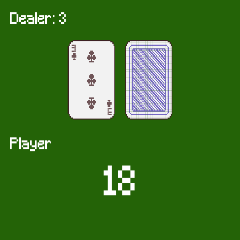

In [67]:
env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=mode)
observation, _ = env.reset()

print(f"{observation}")
img = env.render()
w, h, _ = img.shape
ratio = int(h / w)
new_w, new_h = (ratio * 240), 240
cv2_imshow(cv2.resize(img, (new_w, new_h))) #OpenCV

In [68]:
env.action_space, env.observation_space # Przestrzeń akcji i obseracje

(Discrete(2), Tuple(Discrete(32), Discrete(11), Discrete(2)))

In [69]:
from os import truncate
# 0 - pass
# 1 - dobierz kartę
observation, reward, terminated, truncated, info = env.step(1)

In [70]:
observation, reward, terminated, truncated # Jeśli jeden z parametrów true to koniec gry

((22, 3, 0), -1.0, True, False)

In [71]:
env.close()

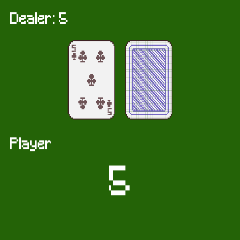

nagroda = -1.0, liczba punktów graczy = 5


In [72]:
def nowa_gra(env):
  observation, info = env.reset()
  img = env.render();
  w, h, _ = img.shape
  ratio = int(h / w)
  new_w, new_h = (ratio * 240), 240
  terminated = False
  truncated = False
  cv2_imshow(cv2.resize(img, (new_w, new_h)))
  time.sleep(0.1)

  if(observation[0] !=21):
    while (not terminated) and (not truncated):
      action = int(input('0 - pas, 1 - dobierz kartę\n'))
      observation, reward, terminated, truncated, info = env.step(action)
      output.clear(wait = True)
      time.sleep(0.1)

      img = env.render();
      cv2_imshow(cv2.resize(img, (new_w, new_h)))
      time.sleep(0.1)
  else:
    observation, reward, terminated, truncated, info = env.step(0)
  print(f"nagroda = {reward}, liczba punktów graczy = {observation[0]}")

env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=mode)
nowa_gra(env)
env.close()

Q-Learning
TO DO: sprawdz ile razy zwycięży skrypt przy losowaniu akcji

In [73]:
#Bez grafiki

def nowa_gra_sample(env):
  observation, info = env.reset()
  terminated = False
  truncated = False
  while (not terminated) and (not truncated):
    action = env.action_space.sample()
    print(f"{action}, obserwation, ", end='')
    observation, reward, terminated, truncated, info = env.step(action)
    print(f"{observation}, {reward}, {terminated}")
  print(f"nagroda = {reward}, liczba punktów gracza = {observation[0]}, liczba punktów przeciwnika = {observation[1]}")

env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=None)
nowa_gra_sample(env)
env.close()

0, obserwation, (12, 10, 0), -1.0, True
nagroda = -1.0, liczba punktów gracza = 12, liczba punktów przeciwnika = 10


Taxi

127


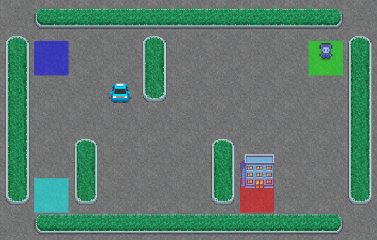

In [74]:
env = gym.make('Taxi-v4' , render_mode=mode) # rgb_array
#env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode='rgb_array') # rgb_array

#observation, info = env.reset()
observation, _ = env.reset()
print(f"{observation}")
img = env.render();
w, h, _ = img.shape
ratio = h/w                 # !!!
new_w, new_h = int(ratio* 240), 240 # !!!
cv2_imshow( cv2.resize(img, (new_w, new_h)) ) # OpenCV
#env.close()

In [75]:
env.action_space, env.observation_space

(Discrete(6), Discrete(500))

In [76]:
def flatten_state(env, obs):
    print(f"# [ info ] {obs}")
    if isinstance(obs, int):
        return obs
    else:
        ans = obs[0];
        prod = 1;
        for n in range(1, len(obs)):
            prod *= env.observation_space[n-1].n
            ans += prod*obs[n]
            #print(f"{prod*obs[n], prod}")
        return ans

observation, _ = env.reset()
flatten_state(env, observation)

# [ info ] 101


101

In [77]:
def nowa_gra_sample(env):
  observation, info = env.reset()
  terminated = False
  truncated = False
  while (not terminated) and (not truncated):
    # implementacja Q-learning --- do zrobienia
    action = env.action_space.sample() # losowo wybrana akcja # !!!!!!!!!!!!!!!!
    #print(f"{action}, {observation}, ", end='')
    observation, reward, terminated, truncated, info = env.step( action )
    #print(f"{observation}, {reward}, {terminated}")
  #print(f"nagroda = {reward}, liczba punktów gracza = {observation[0]}, liczba punktów przeciwnika = {observation[1]}")
  return reward
env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=None)

rewards = 0
draws = 0
for i in range(1000):
  tmp = round(nowa_gra_sample(env))
  if tmp > 0:
    rewards += 1
  elif tmp == 0:
    draws += 1
# rewards
print(f"{100*rewards / 1000.0}%, {rewards}, {draws}, {1000-(rewards+draws)}")


28.0%, 280, 41, 679


In [78]:
env.observation_space, 32*11*2, env.action_space.n

(Tuple(Discrete(32), Discrete(11), Discrete(2)), 704, np.int64(2))

In [79]:
def q_learning(env, episodes = 1000, alpha = 0.5, gamma=0.9, epsilon = 0.8):
  # initialize Q_table
  prod = 1
  if isinstance(env.observation_space, gym.spaces.tuple.Tuple):
      for i in range(len(env.observation_space)): # states in env observation space / flatten
          prod *= env.observation_space[i].n
  else:
      prod = env.observation_space.n

  Q_table = np.zeros([prod, env.action_space.n])
  for episode in range(episodes):
      episode_reward = 0
      observation, info = env.reset()
      terminated = False
      truncated = False
      while (not terminated) and (not truncated):
          state = flatten_state(env, observation)
          if( np.random.rand() < epsilon ): # explore env
              #print("# explore")
              action = env.action_space.sample()
          else:
              #print("# argmax")
              action = np.argmax( Q_table[state, :] ) #[ Q_table[state, a] for a in range(env.action_space.n) ])
            #print(f"action: {action}, {observation}")
          observation, reward, terminated, truncated, info = env.step( action )
          next_state = flatten_state(env, observation)
          episode_reward += reward # BJ opcjonalne

          if(terminated):
              Q_table[state, action] = episode_reward / env.action_space.n
          else:
              Q_table[state, action] += alpha * (reward + gamma * np.max(Q_table[next_state, :]) - Q_table[state, action])

          state = next_state
      epsilon -= epsilon/episodes # !!!!!
      #print(f"{episode}, {epsilon}, {episode_reward}")
  return Q_table
#env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=None)
env = gym.make('Taxi-v4' , render_mode=mode) # rgb_array
Q_table = q_learning(env, episodes=1000)
env.close()

Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
# [ info ] 303
# [ info ] 403
# [ info ] 403
# [ info ] 403
# [ info ] 403
# [ info ] 403
# [ info ] 403
# [ info ] 303
# [ info ] 303
# [ info ] 203
# [ info ] 203
# [ info ] 223
# [ info ] 223
# [ info ] 323
# [ info ] 323
# [ info ] 423
# [ info ] 423
# [ info ] 323
# [ info ] 323
# [ info ] 323
# [ info ] 323
# [ info ] 343
# [ info ] 343
# [ info ] 343
# [ info ] 343
# [ info ] 323
# [ info ] 323
# [ info ] 323
# [ info ] 323
# [ info ] 423
# [ info ] 423
# [ info ] 443
# [ info ] 443
# [ info ] 343
# [ info ] 343
# [ info ] 443
# [ info ] 443
# [ info ] 443
# [ info ] 443
# [ info ] 423
# [ info ] 423
# [ info ] 423
# [ info ] 423
# [ info ] 423
# [ info ] 423
# [ info ] 423
# [ info ] 423
# [ info ] 443
# [ info ] 443
# [ info ] 443
# [ info ] 443
# [ info ] 443
# [ info ] 443
# [ info ] 423
# [ info ] 423
# [ info ] 423
# [ info ] 423
# [ info ] 323
# [ info ] 323
# [ info ] 223
# [ info ] 223
# [ info ] 123
# [ i

In [80]:
print(*Q_table)

[0. 0. 0. 0. 0. 0.] [ -9.89530427  -9.89213133  -9.89545902  -9.89323402  -9.89437608
 -18.82659907] [ -9.82481408  -9.82309213  -9.8269208   -9.8145363   -9.79256221
 -18.76389523] [ -9.86387734  -9.85271788  -9.85751462  -9.85814195  -9.853169
 -18.82927156] [ -9.80934666  -9.80998017  -9.8234119   -9.80716132 -18.73016777
 -18.77117668] [0. 0. 0. 0. 0. 0.] [ -9.89395911  -9.89236393  -9.89152289  -9.88907875 -18.86831726
 -18.8269174 ] [ -9.86203711  -9.86391262  -9.86259769  -9.85937564 -18.83915925
 -18.80111527] [ -9.81555681  -9.81516657  -9.8079176   -9.80871983 -18.59816413
 -18.72785165] [ -9.89977436  -9.90085148  -9.90247836  -9.89823436 -18.85663584
 -18.76963382] [0. 0. 0. 0. 0. 0.] [ -9.85769871  -9.85878304  -9.86447789  -9.85733213 -18.81433975
 -18.81576552] [ -9.8319854   -9.83172289  -9.83078217  -9.83428977 -18.72901538
 -18.83521911] [ -9.87941996  -9.87534626  -9.87713153  -9.87702238 -18.85180909
 -18.80417847] [ -9.8745104   -9.87224411  -9.87555458  -9.8743873

In [65]:
def nowa_gra_q_table(env):
  episode_rewards = 0 #jak black jack to zakomentuj to
  observation, info = env.reset()
  terminated = False
  truncated = False
  while (not terminated) and (not truncated):
    #action = env.action_space.sample()
    state = flatten_state(env, observation)
    action = np.argmax( Q_table[state, :] )
    observation, reward, terminated, truncated, info = env.step( action )
    episode_rewards += reward #jak black jack to zakomentuj to
  return reward
#env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=None)
env = gym.make('Taxi-v4' , render_mode=mode) # rgb_array

#Taxi
rewards = np.zeros((1000, 1))
for i in range(1000):
  rewards[i] = nowa_gra_q_table(env)

#Blackjack
#rewards = 0
#draws = 0
#for i in range(1000):
#  tmp = round(nowa_gra_q_table(env))
#  if tmp > 0:
#    rewards += 1
#  elif tmp == 0:
#    draws += 1



# rewards
#print(f"{rewards}, {100*rewards / 1000.0}%, {draws}, {1000-(rewards+draws)}")
print(f"{sum(rewards)/1000.0}, {max(rewards)}, {min(rewards)}") #to tez taxi

env.close()

Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
# [ info ] 164
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ] 64
# [ info ]